# Chapter 9: Text Processing and Multiclass Classification

Reproduksi dan pembahasan buku John Sukup, *scikit-learn Cookbook*, Third Edition (Packt, 2025). Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_9) beserta exercise solutions. Adaptasi metodologi dijelaskan pada bagian terkait. Dataset sintetis/bawaan dan output di bawah dipakai untuk memahami workflow pembelajaran mesin.

## Daftar Isi

- [Introduction to Text Processing](#introduction-to-text-processing)
- [Text Vectorization Techniques](#text-vectorization-techniques)
- [Feature Extraction from Text](#feature-extraction-from-text)
- [Implementing Text Classification Models](#implementing-text-classification-models)
- [Multiclass Classification Strategies](#multiclass-classification-strategies)
- [Evaluating Text Models](#evaluating-text-models)
- [Practical Exercises in Text Processing](#practical-exercises-in-text-processing)
- [Exercise 3: Building and Evaluating a Multiclass Classifier](#exercise-3-building-and-evaluating-a-multiclass-classifier)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})
chapter_results = {}

## Introduction to Text Processing

Teks perlu diubah menjadi fitur numerik sebelum digunakan oleh estimator scikit-learn. Tokenization memecah teks menjadi token; lowercase menyatukan variasi huruf; stopword removal mengurangi kata umum. Stemming memotong bentuk kata dengan aturan, sedangkan lemmatization mencari bentuk dasar berdasarkan kosakata dan konteks. Menghapus stopword seperti negasi dapat merusak informasi sentimen, sehingga preprocessing dipilih sesuai tujuan.

Movie Reviews memuat 2.000 ulasan dengan label neg/pos. Mengikuti buku, contoh awal mengambil 500 ulasan secara stratified lalu membagi 70% training dan 30% test. CountVectorizer menghasilkan matriks sparse document–term. Vocabulary dipelajari dari training; kata baru yang tidak ada di vocabulary diabaikan saat transform test. Grafik menghitung frekuensi dari matriks sparse tanpa mengubah seluruhnya menjadi array besar.

In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import nltk
from nltk.corpus import movie_reviews, reuters, brown, stopwords
from nltk import ngrams as nltk_ngrams
from collections import Counter
nltk.data.path.insert(0, str(ROOT / '.cache/nltk_data'))
documents = [movie_reviews.raw(fid) for fid in movie_reviews.fileids()]
labels = [movie_reviews.categories(fid)[0] for fid in movie_reviews.fileids()]
sample_idx, _ = train_test_split(np.arange(len(documents)), train_size=500, stratify=labels, random_state=2024)
X_sample = [documents[i] for i in sample_idx]
y_sample = np.array(labels)[sample_idx]
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.3, stratify=y_sample, random_state=2024)
chapter_results['review_sample_training'] = len(X_train)
chapter_results['review_sample_test'] = len(X_test)

In [3]:
# Instantiate and fit CountVectorizer() with stopword removal
vectorizer = CountVectorizer(stop_words='english')
X_train_vect = vectorizer.fit_transform(X_train)

# Transform the test data
X_test_vect = vectorizer.transform(X_test)

chapter_results['count_vocabulary_size'] = X_train_vect.shape[1]

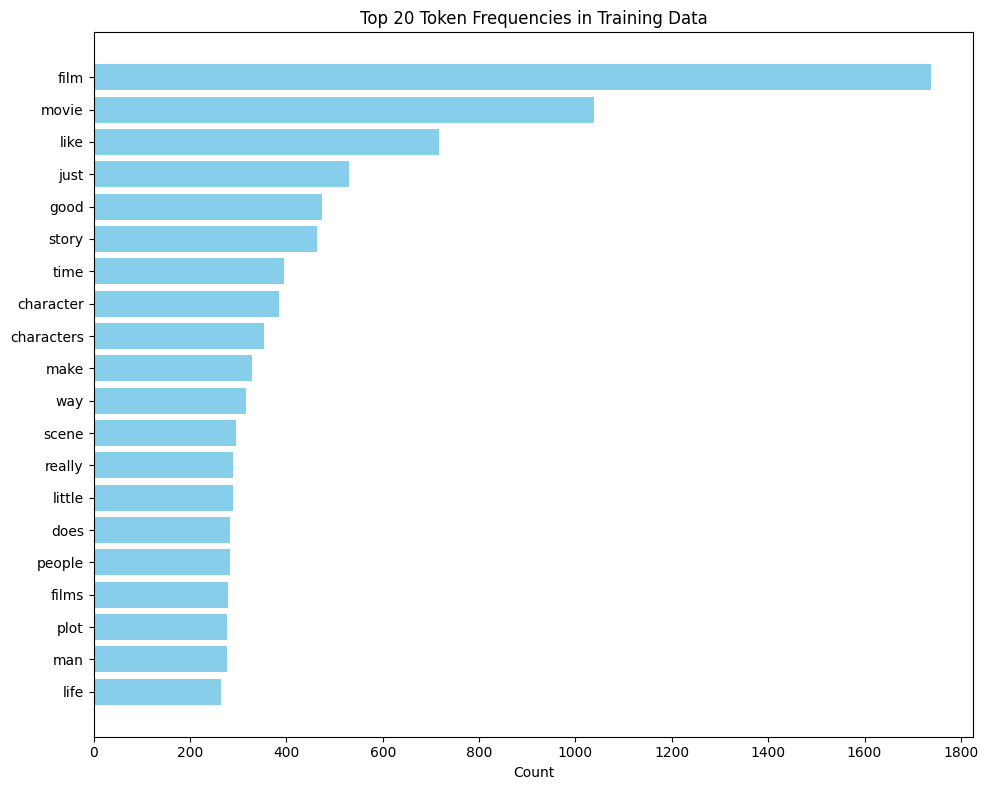

In [4]:
# Visualizing the token counts
feature_names = vectorizer.get_feature_names_out()
counts = np.asarray(X_train_vect.sum(axis=0)).ravel()

top_n = 20 # Display top N features
num_features = len(feature_names) # Should be equal to len(counts)

if num_features > 0:
    # Sort features by count
    # argsort sorts in ascending order, [::-1] reverses it for descending
    sorted_indices = np.argsort(counts)[::-1] 

    actual_top_n = min(top_n, num_features)

    # Select top N features and their counts
    top_feature_names = feature_names[sorted_indices][:actual_top_n]
    top_counts = counts[sorted_indices][:actual_top_n]

    plt.figure(figsize=(10, 8)) # Adjusted figsize for better readability of N items
    plt.barh(top_feature_names, top_counts, color='skyblue')
    plt.xlabel('Count')
    plt.title(f'Top {actual_top_n} Token Frequencies in Training Data')

    # Dynamically set x-axis ticks using MaxNLocator for integer counts
    from matplotlib.ticker import MaxNLocator
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(left=0) # Ensure x-axis starts at 0

    ax.invert_yaxis() # Display the highest count at the top
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else: # num_features == 0
    # Fallback for no features (e.g., if CountVectorizer found no words)
    plt.figure(figsize=(10,6)) # Use original figsize for this fallback
    plt.text(0.5, 0.5, 'No features to display.', ha='center', va='center')
    plt.title('Token Frequency in Training Data')
    plt.xticks([]) # No x-ticks
    plt.yticks([]) # No y-ticks
    plt.show()

## Text Vectorization Techniques

Bag-of-words menyimpan frekuensi token dan mengabaikan urutan. TF-IDF memberi bobot lebih tinggi pada kata yang sering muncul di dokumen tetapi jarang di koleksi. Dengan smoothing default scikit-learn, $idf(t)=\log((1+n)/(1+df(t)))+1$, lalu hasil dikalikan term frequency dan dinormalisasi L2 per dokumen. IDF harus dipelajari hanya dari training. HashingVectorizer memakai hashing tanpa vocabulary terlatih, cocok untuk streaming tetapi dapat mengalami collision dan lebih sulit diinterpretasi.

Reuters dipakai untuk membandingkan representasi pada split acak 50%. Label berita aslinya dapat multilabel; kategori pertama hanya merupakan penyederhanaan contoh buku dan tidak digunakan untuk mengklaim evaluasi multilabel. Nilai rata-rata TF-IDF pada grafik adalah bobot representasi, bukan feature importance model atau bukti kausal.

In [5]:
documents = [reuters.raw(fid) for fid in reuters.fileids()]
labels = [reuters.categories(fid)[0] for fid in reuters.fileids()]
X_train, X_test, y_train, y_test = train_test_split(documents, labels, test_size=0.5, random_state=2024)
print('Reuters documents:', len(documents), '; first-category labels:', len(set(labels)))

Reuters documents: 10788 ; first-category labels: 79


In [6]:
# Bag of Words (BoW)
# Instantiate and fit CountVectorizer()
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# TF-IDF Vectorization 
# Instantiate and fit TfidfVectorizer()
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

assert X_train_tfidf.shape[1] == X_test_tfidf.shape[1]
chapter_results['reuters_tfidf_features'] = X_train_tfidf.shape[1]

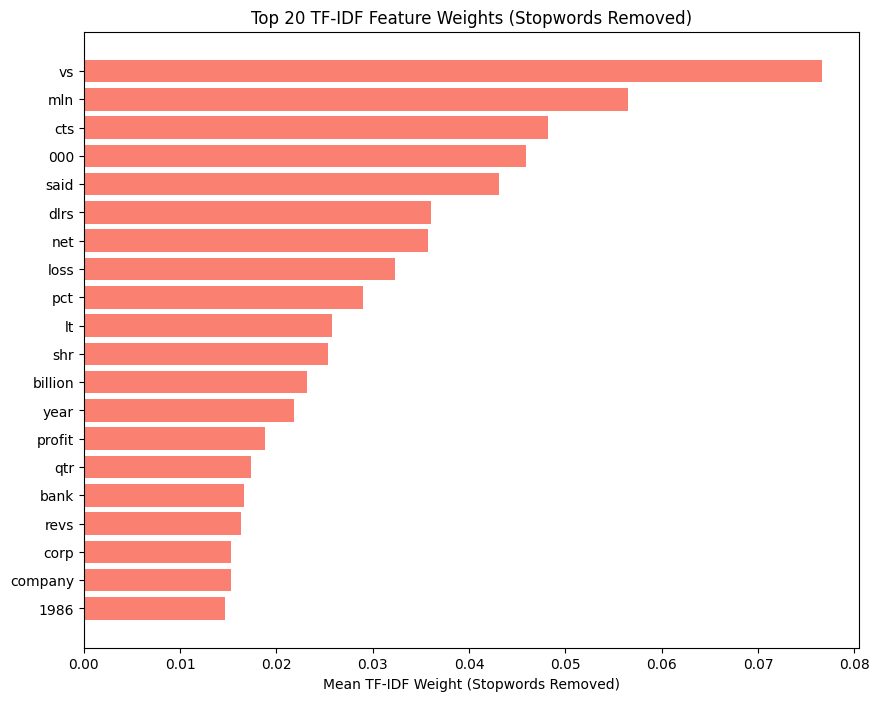

In [7]:
# Visualizing top 20 TF-IDF feature weights
# Create a TfidfVectorizer instance with English stop words removed
vis_tfidf_vectorizer = TfidfVectorizer(stop_words='english')
vis_X_train_tfidf = vis_tfidf_vectorizer.fit_transform(X_train)

# Get feature names and their mean TF-IDF weights from this new vectorization
feature_names = vis_tfidf_vectorizer.get_feature_names_out()
tfidf_means = np.asarray(vis_X_train_tfidf.mean(axis=0)).ravel()

# Number of top terms to display
N = 20

# Ensure N is not greater than the number of available features
if len(feature_names) < N:
    N = len(feature_names)

# Get indices of the N largest TF-IDF means.
# np.argsort sorts in ascending order, so we take the last N indices.
# These indices will correspond to the N features with the highest TF-IDF scores,
# sorted from the Nth highest to the 1st highest (suitable for plt.barh to plot highest at top).
if N > 0 : # Proceed only if there are features to plot
    sorted_indices_ascending = np.argsort(tfidf_means)
    top_n_plotting_indices = sorted_indices_ascending[-N:]

    # Select the top N feature names and their TF-IDF means using these indices
    plot_feature_names = feature_names[top_n_plotting_indices]
    plot_tfidf_means = tfidf_means[top_n_plotting_indices]

    # Create the plot
    plt.figure(figsize=(10, 8)) # Adjusted figsize for better readability with 20 items
    plt.barh(plot_feature_names, plot_tfidf_means, color='salmon')
    plt.xlabel('Mean TF-IDF Weight (Stopwords Removed)')
    plt.title(f'Top {N} TF-IDF Feature Weights (Stopwords Removed)')
else: # Handle case with no features (e.g., if all features were stopwords or N=0)
    plt.figure(figsize=(10, 6)) # Original figsize for empty or minimal plot
    plt.barh([], []) # Plot empty data
    plt.xlabel('Mean TF-IDF Weight (Stopwords Removed)')
    plt.title('TF-IDF Feature Weights (No non-stopword features to display)')

plt.show()

## Feature Extraction from Text

Unigram mewakili satu token; bigram mempertahankan pasangan berurutan, misalnya “not good”, dan dapat menangkap konteks yang hilang pada bag-of-words. N-gram yang panjang memperbesar vocabulary dan sparsity. POS tagging memperkirakan peran gramatikal seperti noun atau verb menggunakan model bahasa; tag bukan label sentimen.

Empat kalimat Brown (dua kategori, dua kalimat per kategori) dipakai hanya untuk demonstrasi ekstraksi. Dua kalimat training bukan dataset yang cukup untuk menilai generalisasi classifier. POS dihitung pada kalimat lengkap, kemudian stopword disaring saat menghitung frekuensi agar konteks tagger tetap tersedia. Model tokenisasi dan tagging berbahasa Inggris; tidak langsung cocok untuk teks Indonesia.

In [8]:
documents, labels = [], []
for category in brown.categories()[:2]:
    for sentence in brown.sents(categories=category)[:2]:
        documents.append(' '.join(sentence))
        labels.append(category)
X_train, X_test, y_train, y_test = train_test_split(documents, labels, test_size=0.5, random_state=2024)
print('Feature extraction demo:', len(X_train), 'training sentences')

Feature extraction demo: 2 training sentences


In [9]:
# N-gram extraction
# Instantiate and fit CountVectorizer() with n-grams
ngram_vectorizer = CountVectorizer(ngram_range=(1,2))
X_train_ngram = ngram_vectorizer.fit_transform(X_train)
X_test_ngram = ngram_vectorizer.transform(X_test)

# Part-of-Speech (POS) Tagging using NLTK

# POS tagging example
print("--- POS Tagging of Tokens and N-grams in Training Sentences ---")
for i, text in enumerate(X_train):
    print(f"\nOriginal Sentence {i+1}: \"{text}\"")
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens) # This returns a list of (token, TAG) tuples

    # Display tagged unigrams (individual tokens with their tags)
    print("  Tagged Tokens (Unigrams):")
    if pos_tags: # Check if list is not empty
        # Format as: token1/TAG1 token2/TAG2 ...
        unigram_str = " ".join([f"{token}/{tag}" for token, tag in pos_tags])
        print(f"    {unigram_str}")
    else:
        print("    (No tokens to tag)")

    # Display tagged bigrams
    # A bigram here means two consecutive (token, TAG) pairs
    if len(pos_tags) >= 2:
        print("  Tagged Bigrams:")
        # nltk_ngrams on pos_tags will yield tuples like ( (token1, TAG1), (token2, TAG2) )
        tagged_bigrams = list(nltk_ngrams(pos_tags, 2))
        for bigram_tuple in tagged_bigrams:
            # bigram_tuple is, e.g., (('The', 'DT'), ('quick', 'JJ'))
            # item1 is ('The', 'DT'), item2 is ('quick', 'JJ')
            item1, item2 = bigram_tuple 
            # Format as: token1/TAG1 token2/TAG2
            bigram_display_str = f"{item1[0]}/{item1[1]} {item2[0]}/{item2[1]}"
            print(f"    {bigram_display_str}")
    else:
        print("  (Not enough tagged tokens for bigrams)")

print("\n--- End of POS Tagging Display ---")

--- POS Tagging of Tokens and N-grams in Training Sentences ---

Original Sentence 1: "Northern liberals are the chief supporters of civil rights and of integration ."


  Tagged Tokens (Unigrams):
    Northern/NNP liberals/NNS are/VBP the/DT chief/JJ supporters/NNS of/IN civil/JJ rights/NNS and/CC of/IN integration/NN ./.
  Tagged Bigrams:
    Northern/NNP liberals/NNS
    liberals/NNS are/VBP
    are/VBP the/DT
    the/DT chief/JJ
    chief/JJ supporters/NNS
    supporters/NNS of/IN
    of/IN civil/JJ
    civil/JJ rights/NNS
    rights/NNS and/CC
    and/CC of/IN
    of/IN integration/NN
    integration/NN ./.

Original Sentence 2: "Dan Morgan told himself he would forget Ann Turner ."
  Tagged Tokens (Unigrams):
    Dan/NNP Morgan/NNP told/VBD himself/PRP he/PRP would/MD forget/VB Ann/NNP Turner/NNP ./.
  Tagged Bigrams:
    Dan/NNP Morgan/NNP
    Morgan/NNP told/VBD
    told/VBD himself/PRP
    himself/PRP he/PRP
    he/PRP would/MD
    would/MD forget/VB
    forget/VB Ann/NNP
    Ann/NNP Turner/NNP
    Turner/NNP ./.

--- End of POS Tagging Display ---


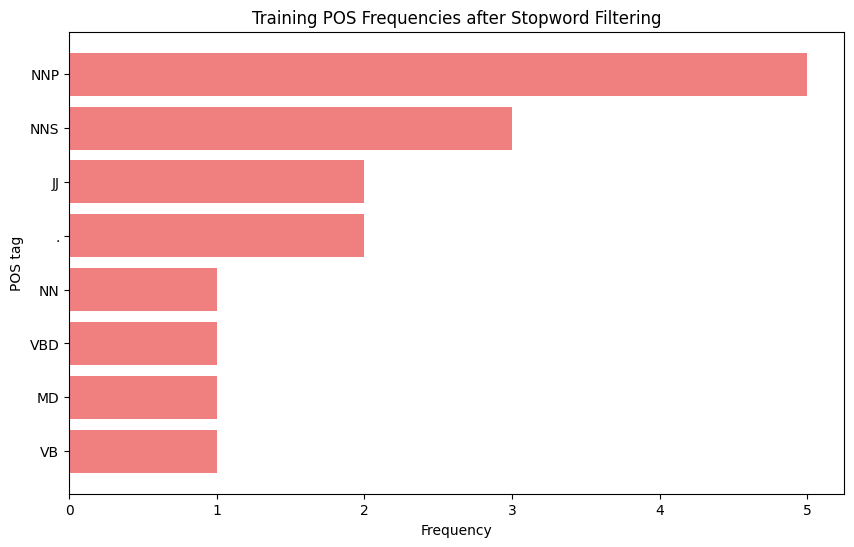

In [10]:
stop_words_set = set(stopwords.words('english'))
pos_tag_counter = Counter(tag for text in X_train
                          for token, tag in nltk.pos_tag(nltk.word_tokenize(text))
                          if token.lower() not in stop_words_set)
tags, counts = zip(*pos_tag_counter.most_common(10))
plt.figure(figsize=(10, 6))
plt.barh(tags, counts, color='lightcoral')
plt.gca().invert_yaxis()
plt.xlabel('Frequency')
plt.ylabel('POS tag')
plt.title('Training POS Frequencies after Stopword Filtering')
plt.show()

## Implementing Text Classification Models

Multinomial Naive Bayes memakai frekuensi/bobot nonnegatif dengan asumsi conditional independence fitur setelah kelas diketahui. SVM mencari batas pemisah dengan margin; logistic regression memodelkan probabilitas kelas. TF-IDF menghasilkan fitur berdimensi tinggi dan sparse, sehingga model linear sering menjadi baseline efisien. Pilihan smoothing, regularisasi, dan kernel tetap perlu validasi.

Brown memiliki 500 dokumen dan 15 genre. Teks diambil dengan `brown.words`, bukan format mentah yang masih berisi anotasi POS. Split stratified 50% menjaga semua genre tersedia. Classification report memakai nama genre dan nol untuk precision yang tidak terdefinisi. Nilai nol tetap menandakan kelas yang gagal diprediksi, bukan kesalahan yang disembunyikan.

In [11]:
documents = [' '.join(brown.words(fid)) for fid in brown.fileids()]
raw_labels = [brown.categories(fid)[0] for fid in brown.fileids()]
unique_raw_labels = sorted(set(raw_labels))
label_to_int = {label:i for i,label in enumerate(unique_raw_labels)}
labels = np.array([label_to_int[label] for label in raw_labels])

X_train, X_test, y_train, y_test = train_test_split(documents, labels, test_size=0.5, stratify=labels, random_state=2024)
display(pd.Series(raw_labels).value_counts().rename('documents'))

learned            80
belles_lettres     75
lore               48
news               44
hobbies            36
government         30
fiction            29
romance            29
adventure          29
editorial          27
mystery            24
religion           17
reviews            17
humor               9
science_fiction     6
Name: documents, dtype: int64

In [12]:
# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# Train a Naive Bayes model
nb_clf = MultinomialNB()
nb_clf.fit(X_train_vect, y_train)

# Train an SVM model
svm_clf = SVC(random_state=2024)
svm_clf.fit(X_train_vect, y_train)

# Train a logistic regression model
lr_clf = LogisticRegression(random_state=2024, max_iter=1000)
lr_clf.fit(X_train_vect, y_train)

# Evaluate the models
models = {'Naive Bayes': nb_clf, 'SVM': svm_clf, 'Logistic Regression': lr_clf}
for name, model in models.items():
    y_pred = model.predict(X_test_vect)
    print(f'{name} Classification Report:')
    # Generate classification report as a dictionary
    # Utilize unique_raw_labels for target_names to show actual class names
    report_dict = classification_report(y_test, y_pred, target_names=unique_raw_labels, output_dict=True, zero_division=0)
    # Convert to DataFrame
    report_df = pd.DataFrame(report_dict).transpose()

    # Stylize the DataFrame
    styled_df = (report_df
        .style
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
        .format({
            'precision': '{:.3f}',
            'recall': '{:.3f}', 
            'f1-score': '{:.3f}',
            'support': '{:.0f}'
        })
    )
    display(styled_df)
    print("\n")

chapter_results['brown_accuracy'] = {name:accuracy_score(y_test, model.predict(X_test_vect)) for name,model in models.items()}

Naive Bayes Classification Report:


,precision,recall,f1-score,support
adventure,0.000,0.000,0.000,15
belles_lettres,0.173,1.000,0.295,37
editorial,0.000,0.000,0.000,14
fiction,0.000,0.000,0.000,14
government,0.000,0.000,0.000,15
hobbies,0.000,0.000,0.000,18
humor,0.000,0.000,0.000,4
learned,0.556,0.500,0.526,40
lore,0.000,0.000,0.000,24
mystery,0.000,0.000,0.000,12


SVM Classification Report:


,precision,recall,f1-score,support
adventure,0.400,0.133,0.200,15
belles_lettres,0.236,0.946,0.378,37
editorial,0.000,0.000,0.000,14
fiction,0.312,0.357,0.333,14
government,0.000,0.000,0.000,15
hobbies,0.000,0.000,0.000,18
humor,0.000,0.000,0.000,4
learned,0.424,0.700,0.528,40
lore,0.000,0.000,0.000,24
mystery,0.000,0.000,0.000,12




Logistic Regression Classification Report:


,precision,recall,f1-score,support
adventure,1.000,0.067,0.125,15
belles_lettres,0.231,0.919,0.370,37
editorial,0.000,0.000,0.000,14
fiction,0.000,0.000,0.000,14
government,0.000,0.000,0.000,15
hobbies,1.000,0.056,0.105,18
humor,0.000,0.000,0.000,4
learned,0.377,0.725,0.496,40
lore,0.000,0.000,0.000,24
mystery,0.000,0.000,0.000,12


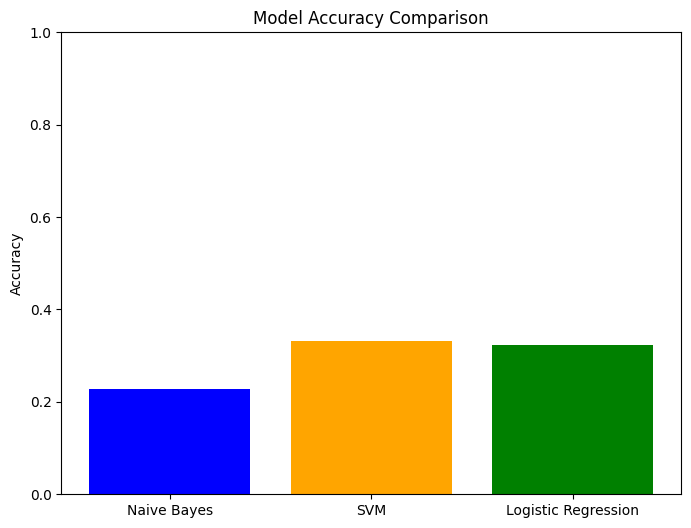

In [13]:
# Visualizing classification accuracies
model_accuracies = {}
for model_name, model_instance in models.items():
    y_pred = model_instance.predict(X_test_vect)
    # Using parameters consistent with the report generation in the preceding cells.
    # Assumes unique_raw_labels is defined and available from a previous cell,
    # The target_names parameter does not affect the overall 'accuracy' value but is included for consistency.
    report_dict = classification_report(y_test, y_pred, target_names=unique_raw_labels, output_dict=True, zero_division=0)
    model_accuracies[model_name] = report_dict['accuracy']

plt.figure(figsize=(8,6))

# Plotting using the calculated accuracies
# .keys() and .values() from the same dictionary will be in corresponding orders.
plt.bar(model_accuracies.keys(), model_accuracies.values(), color=['blue', 'orange', 'green'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

## Multiclass Classification Strategies

One-vs-Rest (OvR) melatih satu classifier untuk tiap kelas melawan kelas lain; untuk K kelas dibutuhkan K model. One-vs-One (OvO) melatih pasangan kelas sebanyak $K(K-1)/2$ lalu menggabungkan keputusan melalui voting. Multinomial logistic regression belajar semua probabilitas dengan softmax. Multiclass berarti satu label per dokumen; multilabel berarti beberapa label dapat benar sekaligus.

Contoh OvR/OvO memakai Brown pada split 70/30 yang berbeda dari bagian sebelumnya. Skor antarbagian tidak boleh ditafsirkan sebagai perbandingan terkontrol karena ukuran training berbeda. Dalam bagian yang sama, vocabulary dan test set identik untuk kedua strategi.

In [14]:
documents = [' '.join(brown.words(fid)) for fid in brown.fileids()]
raw_labels = [brown.categories(fid)[0] for fid in brown.fileids()]
unique_raw_labels = sorted(set(raw_labels))
label_to_int = {label:i for i,label in enumerate(unique_raw_labels)}
labels = np.array([label_to_int[label] for label in raw_labels])

X_train, X_test, y_train, y_test = train_test_split(documents, labels, test_size=0.3, stratify=labels, random_state=2024)

In [15]:
# Vectorize text using TF-IDF
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

vectorizer = TfidfVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# Implement One-vs-Rest classification
ovr_clf = OneVsRestClassifier(LogisticRegression(random_state=2024, solver='liblinear'))
ovr_clf.fit(X_train_vect, y_train)
y_pred_ovr = ovr_clf.predict(X_test_vect)

# Implement One-vs-One classification
ovo_clf = OneVsOneClassifier(LogisticRegression(random_state=2024, solver='liblinear'))
ovo_clf.fit(X_train_vect, y_train)
y_pred_ovo = ovo_clf.predict(X_test_vect)

# Evaluate the classifiers
# Added zero_division=0 to handle cases where precision/recall might be ill-defined
# due to no predicted samples or no true samples for a class.

print('One-vs-Rest Classification Report:')
report_ovr_dict = classification_report(y_test, y_pred_ovr, zero_division=0, output_dict=True)
report_ovr_df = pd.DataFrame(report_ovr_dict).transpose()
styled_ovr_df = (report_ovr_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_ovr_df)
print("\n")

print('One-vs-One Classification Report:')
report_ovo_dict = classification_report(y_test, y_pred_ovo, zero_division=0, output_dict=True)
report_ovo_df = pd.DataFrame(report_ovo_dict).transpose()
styled_ovo_df = (report_ovo_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_ovo_df)
print("\n")

chapter_results['brown_ovr_accuracy'] = accuracy_score(y_test, y_pred_ovr)
chapter_results['brown_ovo_accuracy'] = accuracy_score(y_test, y_pred_ovo)

One-vs-Rest Classification Report:


,precision,recall,f1-score,support
0,1.000,0.111,0.200,9
1,0.256,0.909,0.400,22
2,0.000,0.000,0.000,8
3,0.500,0.222,0.308,9
4,0.000,0.000,0.000,9
5,0.000,0.000,0.000,11
6,0.000,0.000,0.000,3
7,0.400,0.750,0.522,24
8,0.000,0.000,0.000,14
9,0.000,0.000,0.000,7




One-vs-One Classification Report:


,precision,recall,f1-score,support
0,0.000,0.000,0.000,9
1,0.206,0.955,0.339,22
2,0.000,0.000,0.000,8
3,0.000,0.000,0.000,9
4,0.000,0.000,0.000,9
5,0.000,0.000,0.000,11
6,0.000,0.000,0.000,3
7,0.429,0.750,0.545,24
8,0.000,0.000,0.000,14
9,0.000,0.000,0.000,7


## Evaluating Text Models

Accuracy adalah proporsi prediksi benar. Precision mengukur ketepatan prediksi positif, recall mengukur cakupan positif aktual, dan $F1=2PR/(P+R)$. Macro average memberi bobot sama pada tiap kelas; weighted average memberi bobot menurut support sehingga kelas besar dapat menutupi kelemahan kelas kecil. Confusion matrix berisi jumlah prediksi per pasangan label, bukan accuracy tiap kelas.

Seluruh 2.000 Movie Reviews dibagi 50/50 secara stratified. TF-IDF hanya fit pada training. Report dan confusion matrix menunjukkan jenis kesalahan neg/pos. Holdout ini mengevaluasi split tersebut; pemeriksaan domain baru, review duplikat, dan perubahan bahasa tetap diperlukan untuk penggunaan nyata.

In [16]:
documents = [movie_reviews.raw(fid) for fid in movie_reviews.fileids()]
labels = [movie_reviews.categories(fid)[0] for fid in movie_reviews.fileids()]
X_train, X_test, y_train, y_test = train_test_split(documents, labels, test_size=0.5, stratify=labels, random_state=2024)

Precision: 0.7850285028502851
Recall: 0.785
F1 Score: 0.7849946248656215

Classification Report:


,precision,recall,f1-score,support
neg,0.782178,0.790000,0.786070,500.000000
pos,0.787879,0.780000,0.783920,500.000000
accuracy,0.785000,0.785000,0.785000,0.785000
macro avg,0.785029,0.785000,0.784995,1000.000000
weighted avg,0.785029,0.785000,0.784995,1000.000000


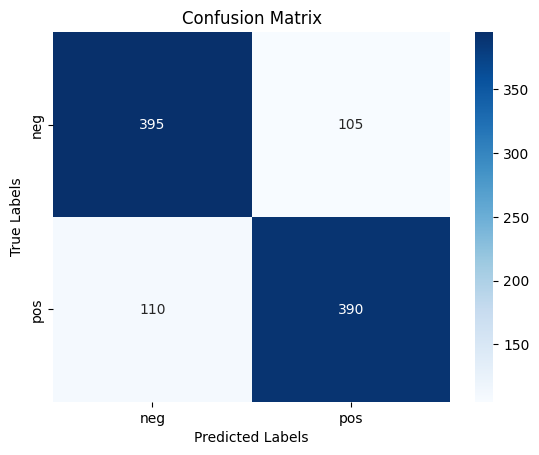

In [17]:
# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# Train a logistic regression classifier
clf = LogisticRegression(random_state=2024)
clf.fit(X_train_vect, y_train)

# Make predictions
y_pred = clf.predict(X_test_vect)

# Evaluate the model
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))

# Generate classification report as a styled DataFrame
report_dict = classification_report(y_test, y_pred, labels=clf.classes_, target_names=clf.classes_, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

print("\nClassification Report:")
display(report_df.style.set_caption("Classification Report"))

# Generate and visualize a confusion matrix
# The confusion matrix contains counts for true/predicted label pairs.
# labels=clf.classes_ ensures the matrix rows/columns follow a consistent order.
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

assert cm.sum() == len(y_test)
chapter_results['sentiment_accuracy'] = accuracy_score(y_test, y_pred)
chapter_results['sentiment_weighted_f1'] = f1_score(y_test, y_pred, average='weighted')
chapter_results['sentiment_test_samples'] = len(y_test)

## Practical Exercises in Text Processing

Exercise 1 melakukan lowercase dan TF-IDF pada empat kalimat pendek sebagai demonstrasi preprocessing. Exercise 2 membuat unigram/bigram dari empat kalimat dan menampilkan vocabulary. Kedua contoh tidak melatih classifier atau menghasilkan skor generalisasi.

In [18]:
# Load libraries
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the Dataset
texts = [
    "Data preprocessing is essential.",
    "Vectorization transforms text.",
    "Clean data improves model performance.",
    "Machine learning algorithms use numerical data."
]

# Preprocess the Data (basic cleaning)
texts_cleaned = [text.lower() for text in texts]

# Vectorize the Text
vectorizer = TfidfVectorizer()
vectorizer.fit_transform(texts_cleaned)

# Print the vectorized features
vectorizer.get_feature_names_out()

array(['algorithms', 'clean', 'data', 'essential', 'improves', 'is',
       'learning', 'machine', 'model', 'numerical', 'performance',
       'preprocessing', 'text', 'transforms', 'use', 'vectorization'],
      dtype=object)

In [19]:
# Load libraries
from sklearn.feature_extraction.text import CountVectorizer

# Load the Dataset
texts = [
    "Feature extraction is crucial.",
    "N-grams capture context.",
    "Models benefit from good features.",
    "Contextual information enhances classification."
]

# Extract N-gram Features
ngram_vectorizer = CountVectorizer(ngram_range=(1,2))
ngram_vectorizer.fit_transform(texts)

# Print the extracted n-gram features
ngram_vectorizer.get_feature_names_out()

array(['benefit', 'benefit from', 'capture', 'capture context',
       'classification', 'context', 'contextual',
       'contextual information', 'crucial', 'enhances',
       'enhances classification', 'extraction', 'extraction is',
       'feature', 'feature extraction', 'features', 'from', 'from good',
       'good', 'good features', 'grams', 'grams capture', 'information',
       'information enhances', 'is', 'is crucial', 'models',
       'models benefit'], dtype=object)

### Exercise 3: Building and Evaluating a Multiclass Classifier

Contoh solusi sumber memiliki empat dokumen dengan empat label, sehingga split menyisakan kelas test yang sama sekali tidak dipelajari. Latihan diperbaiki memakai empat genre Brown dengan banyak dokumen per kelas. Pipeline TF-IDF–LogisticRegression di-fit sesudah split stratified. Accuracy dan macro-F1 dihitung pada test; label kelas dipastikan tersedia pada training maupun test.

In [20]:
selected_genres = ['news', 'editorial', 'reviews', 'fiction']
files = brown.fileids(categories=selected_genres)
texts = [' '.join(brown.words(fid)) for fid in files]
targets = [brown.categories(fid)[0] for fid in files]
train_idx, test_idx = train_test_split(np.arange(len(texts)), test_size=0.3, stratify=targets, random_state=2024)
assert not set(train_idx) & set(test_idx)
assert set(np.array(targets)[train_idx]) == set(np.array(targets)[test_idx])
text_pipe = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000, random_state=2024))
text_pipe.fit([texts[i] for i in train_idx], np.array(targets)[train_idx])
pred = text_pipe.predict([texts[i] for i in test_idx])
print(classification_report(np.array(targets)[test_idx], pred, zero_division=0))
chapter_results['exercise_multiclass_accuracy'] = accuracy_score(np.array(targets)[test_idx], pred)
chapter_results['exercise_multiclass_macro_f1'] = f1_score(np.array(targets)[test_idx], pred, average='macro', zero_division=0)

              precision    recall  f1-score   support

   editorial       0.00      0.00      0.00         8
     fiction       0.90      1.00      0.95         9
        news       0.54      1.00      0.70        14
     reviews       0.00      0.00      0.00         5

    accuracy                           0.64        36
   macro avg       0.36      0.50      0.41        36
weighted avg       0.43      0.64      0.51        36



## Pemeriksaan Hasil

Assertion di bawah memeriksa konsistensi hasil dan keluaran, bukan membuktikan seluruh asumsi statistik.

In [21]:
assert chapter_results
assert chapter_results['sentiment_test_samples'] == 1000
assert 0 <= chapter_results['sentiment_accuracy'] <= 1
assert 0 <= chapter_results['exercise_multiclass_macro_f1'] <= 1
print(json.dumps(chapter_results, indent=2))

{
  "review_sample_training": 350,
  "review_sample_test": 150,
  "count_vocabulary_size": 18881,
  "reuters_tfidf_features": 22864,
  "brown_accuracy": {
    "Naive Bayes": 0.228,
    "SVM": 0.332,
    "Logistic Regression": 0.324
  },
  "brown_ovr_accuracy": 0.35333333333333333,
  "brown_ovo_accuracy": 0.28,
  "sentiment_accuracy": 0.785,
  "sentiment_weighted_f1": 0.7849946248656215,
  "sentiment_test_samples": 1000,
  "exercise_multiclass_accuracy": 0.6388888888888888,
  "exercise_multiclass_macro_f1": 0.4118421052631579
}


## Ringkasan Bab

TF-IDF sentiment Movie Reviews menghasilkan accuracy **0.785** dan weighted-F1 **0.785** pada 1000 review test. Pada Brown, accuracy OvR **0.353** dan OvO **0.280** berasal dari split 70/30 yang sama; report per genre tetap diperlukan karena rata-rata dapat menutupi kelas kecil. Latihan empat genre menghasilkan macro-F1 **0.412** dengan vocabulary dipelajari hanya dari training.

Pelajaran utama: classifier menerima representasi teks, sehingga kualitas tokenisasi, vocabulary, dan split memengaruhi hasil. Skor ini tidak memastikan generalisasi ke bahasa Indonesia atau domain ulasan lain.